In [4]:
import folium
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth
from obspy import UTCDateTime
import matplotlib.pyplot as plt

In [5]:
LATITUDE = 38.90
LONGITUDE = 16.587
RAGGIO_KM = 150

In [6]:
def km_to_deg(km):
    return km / 111.19

In [8]:
#connessione al client
client = Client("INGV")

In [9]:
#scarico le stazioni
inventory = client.get_stations(
    network="IV",
    latitude=LATITUDE,
    longitude=LONGITUDE,
    maxradius=km_to_deg(RAGGIO_KM),
    level="channel"
)

inventory

Inventory created at 2026-03-16T18:41:56.712000Z
	Created by: INGV-ONT WEB SERVICE: fdsnws-station | version: 1.1.63
		    /exist/apps/fdsn-station/fdsnws/station/1/query?network=IV&level=ch...
	Sending institution: eXistDB (INGV-ONT)
	Contains:
		Networks (1):
			IV
		Stations (49):
			IV.ATN (ANTENNAMARE)
			IV.BRICA (Briatico (VV))
			IV.CAR1 (CAROLEI)
			IV.CARO (Carolei)
			IV.CELI (Celico, Cosenza)
			IV.CET2 (Cetraro)
			IV.FERC (GALATRO)
			IV.GIZZ (GIZZ)
			IV.GMB (GAMBARIE)
			IV.GMB1 (GMB1)
			IV.GRI (GIRIFALCO)
			IV.GRIS (Grisolia)
			IV.IPNR (Panarea)
			IV.IST3 (Stromboli-Oss. Fiorentini)
			IV.ISTR (Ginostra)
			IV.JOPP (Joppolo)
			IV.LADO (San Nicola dell Alto)
			IV.MALI (Mali)
			IV.ME03 (Palmi)
			IV.ME04 (Brognaturo)
			IV.ME05 (Diga Del Menta)
			IV.ME09 (Pentedattilo)
			IV.ME10 (Cittanova)
			IV.ME12 (Panarea)
			IV.MILZ (Milazzo Faro)
			IV.MMN (MORMANNO)
			IV.MPAZ (Palizzi)
			IV.MPNC (San Pier Niceto, gia PORTELLA MANDANICI)
			IV.MRCB (Reggio Calabria)
			

In [12]:
#stampo le stazioni
stations = []
for net in inventory:
    for sta in net:
        dist_m, az, baz = gps2dist_azimuth(
            LATITUDE,
            LONGITUDE,
            sta.latitude,
            sta.longitude
        )
        channels = []
        for ch in sta.channels:
            loc = ch.location_code if ch.location_code else "--"
            channels.append(f"{loc}.{ch.code}")

        stations.append({
            "network": net.code,
            "station": sta.code,
            "lat": sta.latitude,
            "lon": sta.longitude,
            "dist_km": dist_m / 1000,
            "channels": channels
        })

In [13]:
stations.sort(key=lambda x: x["dist_km"])

In [14]:
#visualizzo cartina stazioni
m = folium.Map(location=[LATITUDE, LONGITUDE], zoom_start=8)
folium.Circle(
    location=[LATITUDE, LONGITUDE],
    radius=RAGGIO_KM * 1000,
    color="blue",
    fill=False
).add_to(m)

for s in stations:
    popup_html = f"""
    <b>Stazione:</b> {s['network']}.{s['station']}<br>
    <b>Distanza:</b> {s['dist_km']:.1f} km<br>
    <b>Canali:</b><br>
    {'<br>'.join(s['channels'])}
    """
    folium.Marker(
        location=[s["lat"], s["lon"]],
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon()
    ).add_to(m)
m

1 Trace(s) in Stream:
IV.GIZZ..HHZ | 2026-03-16T18:40:26.090000Z - 2026-03-16T18:43:51.590000Z | 100.0 Hz, 20551 samples
Trace ID: IV.GIZZ..HHZ
Campioni: 20551
Sampling rate: 100.0


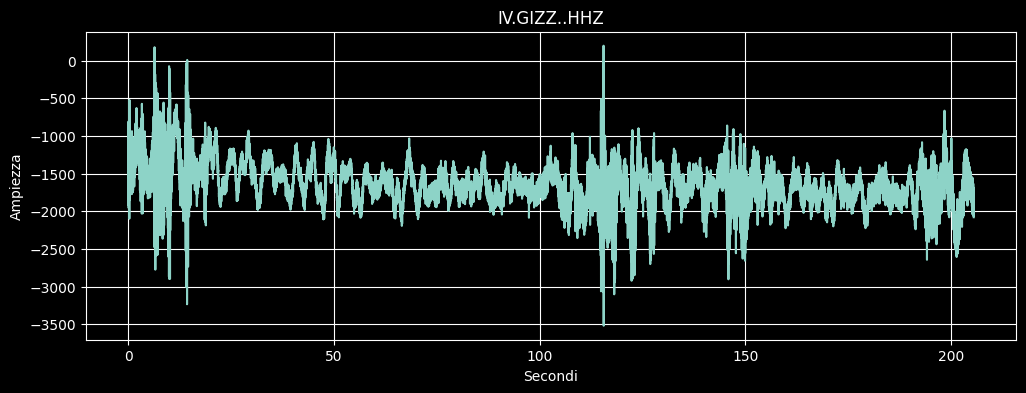

In [16]:
#provo a leggere da una stazione
LOCATION = "*"
NETWORK = "IV"
STATION = "GIZZ"
CHANNEL = "HHZ"
endtime = UTCDateTime.now() -150
starttime = endtime - 250

st = client.get_waveforms(
    network=NETWORK,
    station=STATION,
    location=LOCATION,
    channel=CHANNEL,
    starttime=starttime,
    endtime=endtime
)

print(st)

tr = st[0]

print("Trace ID:", tr.id)
print("Campioni:", tr.stats.npts)
print("Sampling rate:", tr.stats.sampling_rate)

times = tr.times()

plt.figure(figsize=(12,4))
plt.plot(times, tr.data)
plt.title(tr.id)
plt.xlabel("Secondi")
plt.ylabel("Ampiezza")
plt.grid()
plt.show()

Stazione: IV.GIZZ..HHZ
Start: 2026-03-16T18:47:59.160000Z
End: 2026-03-16T18:48:52.550000Z
Campioni: 5340


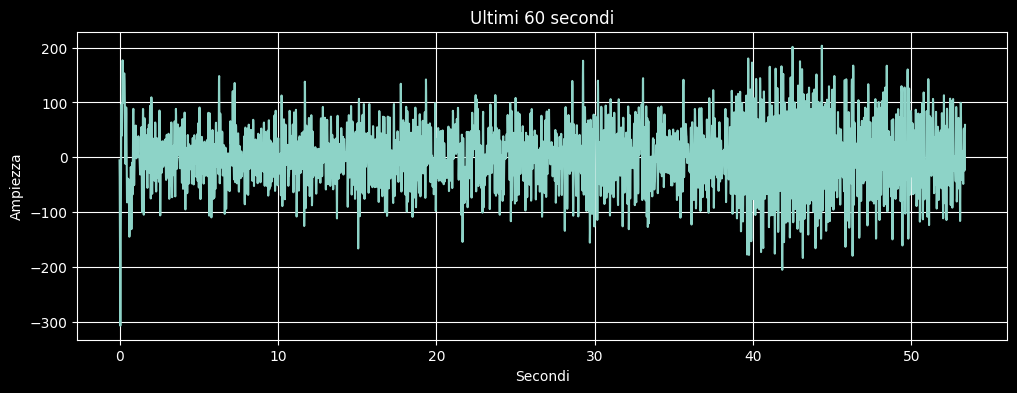

KeyboardInterrupt: 

In [17]:
from obspy.clients.fdsn.header import FDSNNoDataException
from IPython.display import clear_output
import time

WINDOW = 60 #secondi del segnale
INTERVAL = 5 # aggiorna ogni 5 secondi


while True:
    endtime = UTCDateTime.now()
    starttime = endtime - WINDOW

    try:
        st = client.get_waveforms(
            network=NETWORK,
            station=STATION,
            location=LOCATION,
            channel=CHANNEL,
            starttime=starttime,
            endtime=endtime
        )

        tr = st[0].copy()

        tr.detrend("demean")
        tr.detrend("linear")

        tr.filter("bandpass", freqmin=1, freqmax=15)

        times = tr.times()

        clear_output(wait=True)

        print("Stazione:", tr.id)
        print("Start:", tr.stats.starttime)
        print("End:", tr.stats.endtime)
        print("Campioni:", tr.stats.npts)

        plt.figure(figsize=(12,4))
        plt.plot(times, tr.data)
        plt.title("Ultimi 60 secondi")
        plt.xlabel("Secondi")
        plt.ylabel("Ampiezza")
        plt.grid()
        plt.show()

    except FDSNNoDataException:
        print("Nessun dato disponibile, attendo...")
        time.sleep(INTERVAL)
        continue

    except Exception as e:
        print("Errore:", e)
        time.sleep(INTERVAL)
        continue

    time.sleep(INTERVAL)